In [1]:
%load_ext autoreload
%autoreload 2

# load general packages
import numpy as np
import matplotlib.pyplot as plt
import time

# load modules related to this exercise
import NPL_exante as NPL

# Problem set 5

#### 1. Look at the $\texttt{ReadMe.txt}$ to get an overview of the code

#### 2. Find the formula for $P=\Lambda(V_{\sigma})$, $V_{\sigma}=\psi(P)$ and $P=\Psi(P)$, exploiting the Extreme Value Type 1 distribution for $\epsilon$. 

Insert the formulars under $\texttt{psi}$ ($V_{\sigma}=\psi(P)$) and $\texttt{lambdaa}$ ( $P=\Lambda(V_{\sigma})$) in the functions below.

In the next cell, we import the solution algorithm from $\texttt{01\_02\_NFXP}$ and the model-file such that we can append functions to the model, which makes the NPL algorithm run. In this way, we avoid having the same model-file in several directories.

In [2]:
import sys
sys.path.append('../01_02_NFXP')
import solve_NFXP
import estimate_NFXP
from model_zurcher import zurcher

In [3]:
def unc_state_transition(self,pk):

    # 1. compute unconditional transition matrix
    self.Fu = self.P1*pk[:, None] + self.P1[0,:]*(1-pk[:,None]) 
    
    # 2. compute [I-Fu]^{-1}
    self.Finv = np.linalg.inv(np.identity(self.n)-self.beta*self.Fu)
    
def Psi(self, pk0, Finv=None):
    '''Evaluate Psi function (mapping from initial CCP to updated CCP)'''
    
    # 1. evaluate psi function (find Vsigma implied by initial CCP)
    self.psi(pk0, Finv)
    
    # 2. evaluate lambda function (find updated CCP implied by Vsigma)
    pk = self.lambdaa()
    
    return pk

def psi(self,pk,Finv=None):
    '''Evaluate psi function (mapping from initial CCP to Vsigma)'''
    
    # 1. compute [I-Fu]^{-1} if not given
    if Finv is None:
        self.unc_state_transition(pk)
    
    # 2. euler constant
    eulerc = np.euler_gamma
    
    # 3. compute Vsigma
    # FILL IN. Use the small psi mapping from the slides
    # Hint:  1) compute expected utility for keeping and replacing
    #           (make sure to get E[\epsilon(a)|a,x] correct)

    ### SOLUTION ###
    util_keep = -self.cost + eulerc - np.log(pk) # shape (n,)
    util_replace = -self.RC - self.cost[0] + eulerc - np.log(1-pk) # shape (n,)
    util_expected = pk * util_keep + (1 - pk)*util_replace # shape (n,)
    self.Vsigma = (self.Finv @ util_expected).flatten() # shape (n,)
    ### SOLUTION ###

    #self.Vsigma = 

def lambdaa(self):
    '''Evaluate lambda function (mapping from Vsigma to updated CCP)'''
    
    # compute updated CCP (pk)
    # FILL IN. Delete "None". Use the big lambda mapping from the slides.
    # This is just the choice probability expression as used in NFXP
    # Hint:  1) compute value-choice functions
    #        2) compute conditional choice probability of keeping engine
    
    pk = None

    ### SOLUTION ###
    value_keep = -self.cost + self.beta * self.P1 @ self.Vsigma
    value_replace = -self.RC - self.cost[0] + self.beta * self.P2 @ self.Vsigma
    pk = 1/(1+np.exp(value_replace-value_keep))
    ### SOLUTION ###

    return  pk

# add to the model-file
zurcher.unc_state_transition = unc_state_transition
zurcher.Psi = Psi
zurcher.psi = psi
zurcher.lambdaa = lambdaa

#### 3. Solve the model using NPL, and plot the convergence of psi to check that your results are correct

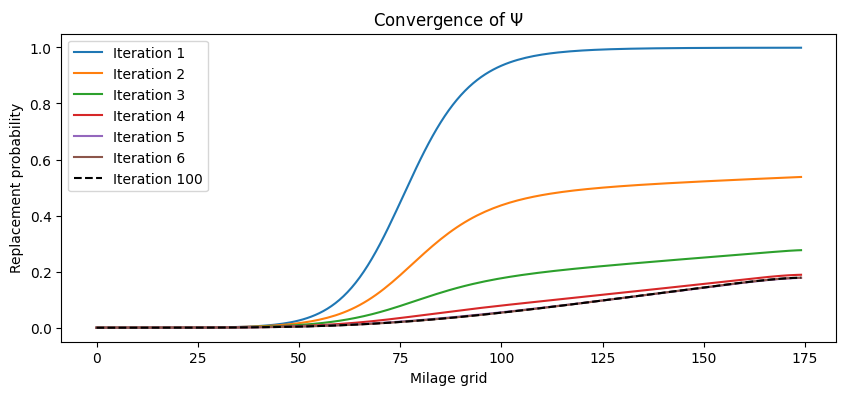

In [4]:
# 1. set up mdoel
model = zurcher()

# 2. solve model
pk_NPL = NPL.solve(model)

fig, ax = plt.subplots(figsize=(10,4)) 

ax.set_title(rf'Convergence of $\Psi$')
ax.set_xlabel('Milage grid')
ax.set_ylabel('Replacement probability')
for i in range(6): ax.plot(model.grid,1-pk_NPL[i+1,:],label=f'Iteration {i+1}')
ax.plot(model.grid,1-pk_NPL[99,:],label=f'Iteration 100',color='black',linestyle='--')
ax.legend();

#### 4. Now you have to compare NFXP and NPL. Calculate the CCPs from either method and compare the results.

Remeber that NFXP solve the fixed-point problem in (integrated) value function space: $\bar{V}=\bar{\Gamma}(\bar{V})$ and NPL solves it in CCP space: $P=\Psi(P)$

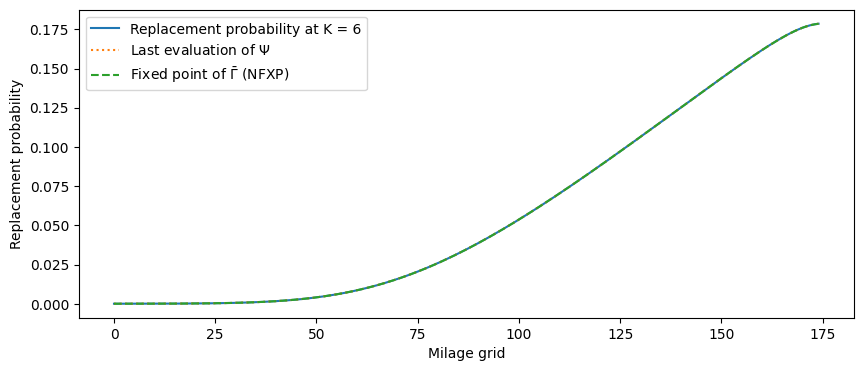

In [5]:
# 1. solve the model with NFXP (like earlier exercises)
Vbar0 = np.zeros(model.n)
solver_NFXP = solve_NFXP.solve_NFXP()
_, pk_NFXP = solver_NFXP.poly(model.bellman, Vbar0, beta=model.beta, output=2)

# Define figure
fig, ax = plt.subplots(figsize=(10,4)) 

ax.plot(model.grid,1-pk_NPL[6,:],label=rf'Replacement probability at K = 6')
ax.plot(model.grid,1-pk_NPL[99,:],label=rf'Last evaluation of $\Psi$', ls='dotted')
ax.plot(model.grid,1-pk_NFXP,label=r'Fixed point of $\bar{\Gamma}$ (NFXP)', ls='dashed')

ax.set_xlabel('Milage grid')
ax.set_ylabel('Replacement probability')
ax.legend();

#### 5. $F^{U}(P)$ is the unconditional transition probabilities induced by pk (vector) - what does that mean? 
(a) How does it differ from the transition matrices P.

#### 6. What determines if NFXP is computationally cheaper to use than NPL? Think about what is in the inner loop of either algorithm. 

#### 7. Now we have to Estimate the model using NPL. In order to estimate the model you should understand 
<il type ="a">
<li> NPL.estimate </li>
<li> NPL.ll (skip the part of computing the gradient and the hessian)</li>
</il>

#### 8. Fill in the missing stuff in NPL.ll, and run the code below to check that your results are correct

In [6]:
# 1. setup
Kmax = 10 # max number of outer loop iterations for NPL 
pnames = ['RC','c']
model = zurcher()
model.dc = 0.001*model.grid # add du_dc for score computation

# 2. load data
data = model.read_busdata(bustypes=[1,2,3,4])
data_class = NPL.setup_data(data)
samplesize = data_class.x.size

# 3. estimate using NPL
t0 = time.time()
res, theta_hat,pk = NPL.estimate(model, data_class, Kmax)
time_ = time.time() - t0

# 4. print the results for NPL
print(f'Structual estimation using busdata from Rust(1987)')
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')
print(f'Sample size = {samplesize}')

print('\n \nNPL \n--------------------------------')
print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat[0]:.4f}     ')
print(f'{pnames[1]}              {theta_hat[1]:.4f}      \n ')

print(f'Log-likelihood {-res.fun*samplesize:.4f}') 
print(f'runtime (seconds) {(time_):.4f}')

# 5. estimate using NFXP
theta0 = [0, 0]
solver_NFXP = solve_NFXP.solve_NFXP()
t0 = time.time()
nfxp_model, optim_res, pnames, theta_hat, Avar, converged=estimate_NFXP.estimate(model, solver_NFXP,data,theta0=theta0, twostep=0)
time_ = time.time()-t0

# 6. print the results for NFXP
print('\n \nNFXP \n--------------------------------')
print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
print(f'{pnames[1]}              {theta_hat[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')

print(f'Log-likelihood {-optim_res.fun*samplesize:.2f}') 
print(f'runtime (seconds) {time_:.4f}')

Structual estimation using busdata from Rust(1987)
Beta        = 0.9999
n           = 175
Sample size = 8156

 
NPL 
--------------------------------
Parameters     Estimates    s.e. 
RC             9.7711     
c              1.3433      
 
Log-likelihood -300.5699
runtime (seconds) 0.7734

 
NFXP 
--------------------------------
Parameters     Estimates    s.e. 
RC             9.7689     1.2260 
c              1.3427     0.3152 
 
Log-likelihood -300.57
runtime (seconds) 6.0180
